<a href="https://colab.research.google.com/github/huwperkins08-lang/TSF_seepage_detection_ElSoldado/blob/main/REP_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap.core as geemap

# 1. INITIALIZATION
ee.Authenticate()
ee.Initialize(project='sxe390-el-soldado')

# 2. DEFINE LOCATION & STUDY AREA (The "Ethical Clip")
# El Soldado Mine, Chile
lat, lon = -32.65, -71.16
mine_site = ee.Geometry.Point([lon, lat])
study_area = mine_site.buffer(20000) # 5km buffer to limit computing power

# 3. CLOUD MITIGATION FUNCTION (QA60)
def mask_s2_clouds(image):
    qa = image.select('QA60')
    # Bits 10 and 11 are clouds and cirrus
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
           qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    # Return masked image and scale to 0-1 reflectance
    return image.updateMask(mask).divide(10000)

def resample_to_10m(image):
    # Select the bands that are natively 20m (Red Edge)
    # We include B8A because it's often used in advanced vegetation indices
    bands_20m = ['B5', 'B6', 'B7', 'B8A']

    # Select the 10m bands to use as a projection/scale template
    template_10m = image.select('B4')

    # Resample the 20m bands using bilinear interpolation
    resampled_bands = (image.select(bands_20m)
                       .resample('bilinear')
                       .reproject(
                           crs=template_10m.projection().crs(),
                           scale=10
                       ))

    # Replace the old 20m bands with the new smooth 10m versions
    return image.addBands(resampled_bands, overwrite=True)

# 4. SOURCE & FILTER DATA
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(mine_site)
                  .filterDate('2023-12-01', '2024-04-01')
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
                  .map(mask_s2_clouds) #1. CLean the clouds
                  .map(resample_to_10m)) #2 Resize pixels

# Create the Median (Noise Reduction) and Clip
base_median = s2_collection.median().clip(study_area)

# 5. TOPOGRAPHIC & SPECTRAL NORMALIZATION
# We use a Band Ratio approach to level out terrain shading
# Normalizing by the mean of all bands reduces the 'hill-shadow' effect
img_mean = base_median.reduce(ee.Reducer.mean())
topo_corrected = base_median.divide(img_mean)

# 6. NDVI MASKING (Vegetation Isolation)
ndvi = base_median.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndvi_mask = ndvi.gt(0.3)

# 7. CONTINUUM REMOVAL (CR) & REP CALCULATION
# Isolate chlorophyll from background interference
continuum = base_median.select('B7')
b4_cr = base_median.select('B4').divide(continuum)
b5_cr = base_median.select('B5').divide(continuum)
b6_cr = base_median.select('B6').divide(continuum)
b7_cr = ee.Image(1) # B7/B7 reference point

# Calculate REP on the CR-cleaned bands
rep_cr = ee.Image(700).add(
    ee.Image(40).multiply(
        ( (b4_cr.add(b7_cr).divide(2)).subtract(b5_cr) ).divide(b6_cr.subtract(b5_cr))
    )
).rename('REP_CR').updateMask(ndvi_mask)

# 8. VISUALIZATION
Map = geemap.Map(center=[-32.65, -71.16], zoom=13)

# Layer 1: Natural Color for context
Map.addLayer(base_median, {'bands':['B4','B3','B2'], 'min':0, 'max':0.3}, '1. Natural Color')

# Layer 2: The Final Product (REP with CR and NDVI Mask)
rep_params = {'min': 705, 'max': 725, 'palette': ['red', 'orange', 'yellow', 'green']}
Map.addLayer(rep_cr, rep_params, '2. REP (Continuum Removed)')

# 1. Define two comparison points
# Impact site (near the tailings/mine)
impact_pt = ee.Geometry.Point([-71.18, -32.64]).buffer(300)

# Control site (away from the mine in a similar valley)
control_pt = ee.Geometry.Point([-71.27, -32.70]).buffer(300)

# 2. Extract the Mean REP for both
impact_stats = rep_cr.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=impact_pt,
    scale=10
)

control_stats = rep_cr.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=control_pt,
    scale=10
)

# 3. Print the results to the console
print('--- RESULTS ---')
print('Impact Site Mean REP:', impact_stats.get('REP_CR').getInfo())
print('Control Site Mean REP:', control_stats.get('REP_CR').getInfo())

# 4. Add the circles to the map so you can see where they are
Map.addLayer(impact_pt, {'color': 'red'}, 'Impact Buffer (300m)', False)
Map.addLayer(control_pt, {'color': 'blue'}, 'Control Buffer (300m)', False)

Map

--- RESULTS ---
Impact Site Mean REP: 716.62062716501
Control Site Mean REP: 717.0144655687077


Map(center=[-32.65, -71.16], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

In [25]:
import geopandas as gpd
import ee
import geemap # Use top-level geemap for ee_to_df

# 1. Load  QGIS GeoJSON
gdf = gpd.read_file('sites_final_300m.geojson')

# 2. Convert to Earth Engine FeatureCollection
def geodf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        # Convert QGIS geometry to EE geometry using the full GeoJSON interface
        # This handles various geometry types (Polygon, MultiPolygon, etc.) robustly.
        ee_geometry = ee.Geometry(row.geometry.__geo_interface__)
        f = ee.Feature(ee_geometry, row.drop('geometry').to_dict())
        features.append(f)
    return ee.FeatureCollection(features)

study_sites = geodf_to_ee(gdf)

# 3. Extract EVERY pixel value (REP) for each site
# This creates a table where each row is a 10m pixel
pixel_data = rep_cr.sampleRegions(
    collection=study_sites,
    properties=['site_type'], # This links the pixel to your QGIS label
    scale=10,
    geometries=True # Keeps the lat/long of each pixel if needed
)

# 4. Convert the massive amount of data to a Pandas DataFrame
# Use geemap.ee_to_df for direct conversion of FeatureCollection to DataFrame
# Ensure 'site_name' is explicitly selected as a property for conversion
df_pixels = geemap.ee_to_df(pixel_data.select(['REP_CR','site_type']))

print(f"Successfully extracted {len(df_pixels)} individual pixel values!")
print(df_pixels.head())

Successfully extracted 19024 individual pixel values!
       REP_CR site_type
0  715.115234      Test
1  715.115234      Test
2  713.226868      Test
3  720.021362      Test
4  716.688721      Test


In [26]:
# This will show exactly how many pixels were found for each site type
print("Breakdown of pixels by Site Type:")
print(df_pixels['site_type'].value_counts())

# This will show the average REP value for Test vs Control
print("\nMean REP values:")
print(df_pixels.groupby('site_type')['REP_CR'].mean())


Breakdown of pixels by Site Type:
site_type
Control_3    3361
Control_5    3321
Control_1    3234
Control_4    3203
Control_2    3106
Test         2799
Name: count, dtype: int64

Mean REP values:
site_type
Control_1    716.689672
Control_2    715.711989
Control_3    717.610236
Control_4    717.029506
Control_5    718.248164
Test         715.752458
Name: REP_CR, dtype: float64


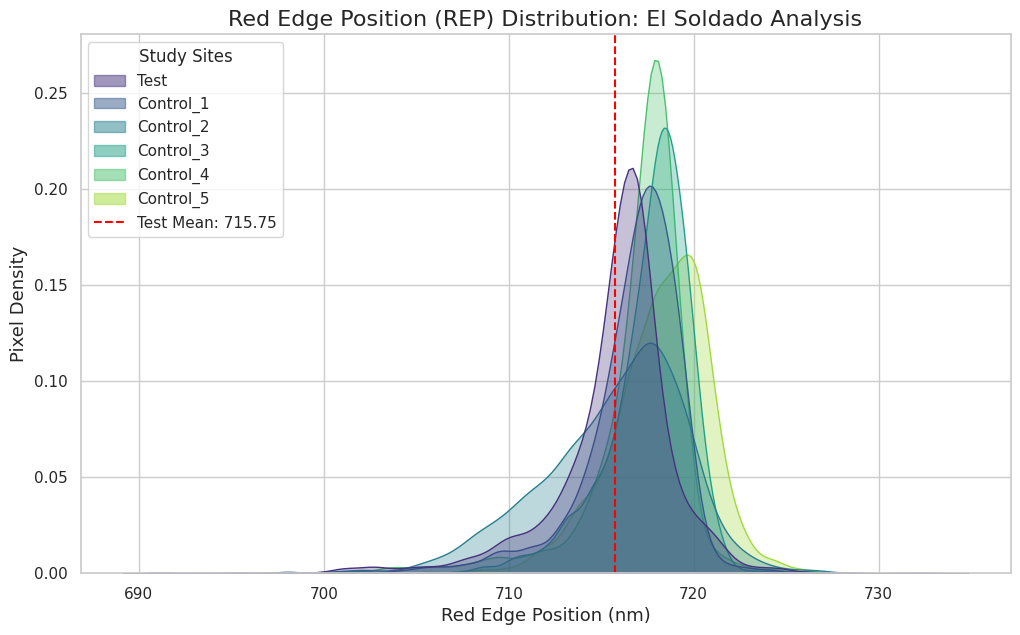

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Prepare the Data - we ensure 'Test' is the first color (Purple)
site_names = ['Test', 'Control_1', 'Control_2', 'Control_3', 'Control_4', 'Control_5']
colors = sns.color_palette('viridis', n_colors=len(site_names))

plt.figure(figsize=(12, 7))

# 2. Draw the curves - we use the exact same order here
sns.kdeplot(data=df_pixels, x='REP_CR', hue='site_type', hue_order=site_names,
            fill=True, common_norm=False, palette='viridis', alpha=0.3)

# 3. Add the Mean Line
test_mean = df_pixels[df_pixels['site_type'] == 'Test']['REP_CR'].mean()
mean_line = plt.axvline(test_mean, color='red', linestyle='--', label=f'Test Mean: {test_mean:.2f}')

# 4. Create the Legend handles manually to match the order
legend_handles = []
for i, name in enumerate(site_names):
    patch = mpatches.Patch(color=colors[i], label=name, alpha=0.5)
    legend_handles.append(patch)
legend_handles.append(mean_line)

# 5. Final Plot Touches
plt.legend(handles=legend_handles, title="Study Sites", loc='upper left', frameon=True)
plt.title('Red Edge Position (REP) Distribution: El Soldado Analysis', fontsize=16)
plt.xlabel('Red Edge Position (nm)', fontsize=13)
plt.ylabel('Pixel Density', fontsize=13)

plt.show()

In [36]:
# 1. Create a clean filename
filename = 'El_Soldado_REP_Raw_Data_23_24.csv'

# 2. Export the entire DataFrame to CSV
# This includes every single pixel's value and its site name
df_pixels.to_csv(filename, index=False)

print(f"Success! '{filename}' has been created.")
print("Look in the folder icon on the left of your screen to download it.")

Success! 'El_Soldado_REP_Raw_Data_23_24.csv' has been created.
Look in the folder icon on the left of your screen to download it.


In [37]:
import scipy.stats as stats

# 1. Group the data by site
groups = [group['REP_CR'].values for name, group in df_pixels.groupby('site_type')]

# 2. Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("--- ANOVA RESULTS ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value:     {p_value:.10f}")

# 3. Quick interpretation
if p_value < 0.05:
    print("\nResult: STATISTICALLY SIGNIFICANT")
    print("There is a significant difference in the Red Edge Position between your sites.")
else:
    print("\nResult: NOT SIGNIFICANT")

--- ANOVA RESULTS ---
F-Statistic: 349.2186
P-Value:     0.0000000000

Result: STATISTICALLY SIGNIFICANT
There is a significant difference in the Red Edge Position between your sites.


In [38]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Perform Tukey's Honestly Significant Difference (HSD) test
tukey = pairwise_tukeyhsd(endog=df_pixels['REP_CR'],
                          groups=df_pixels['site_type'],
                          alpha=0.05)

# 2. Print the results table
print("--- TUKEY POST-HOC TEST RESULTS ---")
print(tukey)

# 3. Optional: Export this table to a CSV for your report
import pandas as pd
tukey_data = pd.DataFrame(data=tukey._results_table.data[1:],
                          columns=tukey._results_table.data[0])
tukey_data.to_csv('tukey_results_elsoldado.csv', index=False)

--- TUKEY POST-HOC TEST RESULTS ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Control_1 Control_2  -0.9777    0.0 -1.1944  -0.761   True
Control_1 Control_3   0.9206    0.0  0.7081   1.133   True
Control_1 Control_4   0.3398 0.0001  0.1248  0.5548   True
Control_1 Control_5   1.5585    0.0  1.3454  1.7716   True
Control_1      Test  -0.9372    0.0 -1.1599 -0.7145   True
Control_2 Control_3   1.8982    0.0  1.6836  2.1129   True
Control_2 Control_4   1.3175    0.0  1.1003  1.5347   True
Control_2 Control_5   2.5362    0.0  2.3209  2.7515   True
Control_2      Test   0.0405 0.9957 -0.1843  0.2653  False
Control_3 Control_4  -0.5807    0.0 -0.7937 -0.3677   True
Control_3 Control_5   0.6379    0.0  0.4269   0.849   True
Control_3      Test  -1.8578    0.0 -2.0785 -1.6371   True
Control_4 Control_5   1.2187    0.0   1.005  1.4323   True
Control_4      Test 